In [1]:
#Read data
import pandas as pd

train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")
print(train_df.info())
print(test_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 428 entries, 0 to 427
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Id        428 non-null    int64 
 1   Article   428 non-null    object
 2   Category  428 non-null    object
dtypes: int64(1), object(2)
memory usage: 10.2+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106 entries, 0 to 105
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Id        106 non-null    int64 
 1   Article   106 non-null    object
 2   Category  106 non-null    object
dtypes: int64(1), object(2)
memory usage: 2.6+ KB
None


In [2]:
#Task 1 - done locally in this implementation, not using David's task 1 implementation
#Load data
#Conduct term frequency analysis

from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(max_features = 2000)

#Creating datasets
X_train = vectorizer.fit_transform(train_df['Article'])
X_test = vectorizer.transform(test_df['Article'])

#Prediction datasets
y_train = train_df['Category']
y_test = test_df['Category']

There are 534 instances in the dataset; 428 in training and 106 in testing. The dataset has three attributes; 
ID, Article, Category. Article contains preprocessed text data, category stores 'tech' or 'entertainment' label.
TF-IDF vectorization was used for converting the text articles to a numerical representation that the model can learn on. 
A max vocabulary size of 2000 was set. This was done to emphasize important words and deemphasize unimportant words.

In [3]:
#Step to reduce the data to 2D for visualization in later tasks
from sklearn.decomposition import PCA 

#Convert it to an array
X_train_convert = X_train.toarray()
pca = PCA(n_components = 2) #For 2 dimensions
X_train_2d = pca.fit_transform(X_train_convert)

In [4]:
#Build the model and set hyperparameters
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors = 5, metric = 'euclidean') #build the model and set hyperparameters
knn_model.fit(X_train_2d, y_train)

KNeighborsClassifier(metric='euclidean')

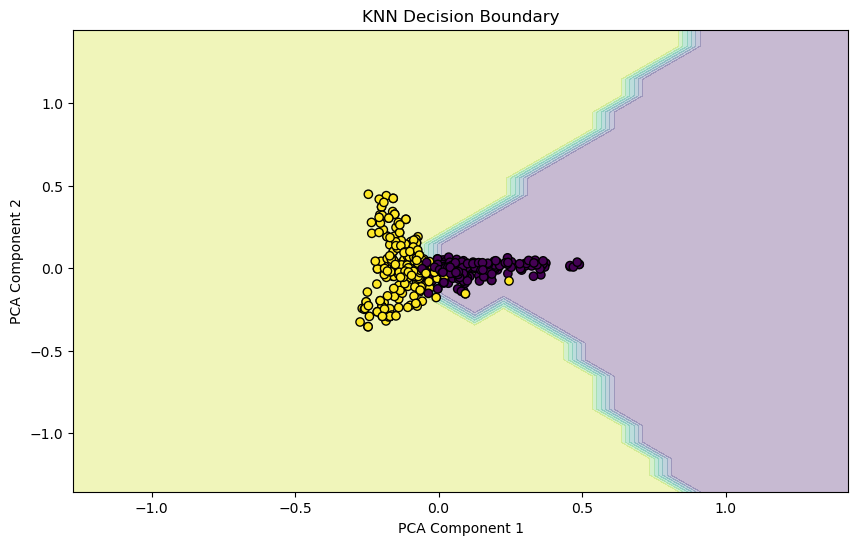

In [5]:
#Create the plot
import numpy as np
import matplotlib.pyplot as plt

#Find PCA Plot Limtis

x_min = X_train_2d[:, 0].min() - 1
x_max = X_train_2d[:, 0].max() + 1
y_min = X_train_2d[:, 1].min() - 1
y_max = X_train_2d[:, 1].max() + 1

#Create a grid as the graph
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1)) 

#Make predictions and make co-ordinates for points, make labels as numbers
Z = knn_model.predict(np.c_[xx.ravel(), yy.ravel()]) #
Z = np.array([1 if z == 'tech' else 0 for z in Z])
Z = Z.reshape(xx.shape)
y_numeric = np.array([1 if y == 'tech' else 0 for y in y_train])

#Define the plot
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha = 0.3)

#Plot the points, define axes
scatter = plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c = y_numeric, edgecolor = 'k')
plt.title("KNN Decision Boundary")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()


#  Choice of hyperparameters

### PCA reduction

TF-IDF vectorization in this case has up to 2000 features/dimensions for an instance. Because this can't be visualized directly, I used PCA to reduce this to 2 dimensions, preserving as much variance as possible, so I can plot it and visualise the decision boundaries.

### Impact of K

A small k is very sensitive to noise, overfitting, outliers. It will produce more complex and uneven boundaries. This makes it more sensitive to noise and overfitting because it is not influenced by many neighbouring points. A larger K will produce smoother, more even boundaries because predictions are influenced by more neighbouring points.

### Distance metric

Euclidean Distance measures the straight line distance between points in the feature space. It creates smooth, circular regions. Manhattan Distance creates more box like regions. Manhattan and Euclidean Distance will produce slightly different boundaries.

# Hyperparameter investigation

Analysed Hyperparameters by using k-fold CV. 

In [6]:
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

k_neighbours_values = [1,3,5,7,15] 

print("Metrics with Cosine Distance")
for v in k_neighbours_values:
    knn = KNeighborsClassifier(n_neighbors = v, metric = 'cosine')
    scores = cross_val_score(knn, X_train, y_train, cv = 5, scoring = 'f1_macro') #set cv = 5
    
    print(f"k = {v}")
    print("Scores: ", scores)
    print(f"Average F1: , {np.mean(scores)} \n")
    
print("Metrics with Euclidean Distance")
for v in k_neighbours_values:
    knn = KNeighborsClassifier(n_neighbors = v, metric = 'euclidean')
    scores = cross_val_score(knn, X_train, y_train, cv = 5, scoring = 'f1_macro') #set cv = 5
    
    print(f"k = {v}")
    print("Scores: ", scores)
    print(f"Average F1: , {np.mean(scores)} \n")

print("Metrics with Manhattan Distance")
for v in k_neighbours_values:
    knn = KNeighborsClassifier(n_neighbors = v, metric = 'manhattan')
    scores = cross_val_score(knn, X_train, y_train, cv = 5, scoring = 'f1_macro') #set cv = 5
    
    print(f"k = {v}")
    print("Scores:", scores)
    print(f"Average F1:, {np.mean(scores)} \n")
    
    
#Best F1 average score was found with Cosine and Euclidean Distances which have identical scores. With k = 15 as well. 
#Manhattan performed significantly worse than both.

Metrics with Cosine Distance
k = 1
Scores:  [0.9767316  0.9534632  0.9418526  0.95288248 0.98822878]
Average F1: , 0.962631733770596 

k = 3
Scores:  [0.98835793 0.93019481 0.96511156 0.96462755 0.98822878]
Average F1: , 0.9673041238444373 

k = 5
Scores:  [1.         0.9418526  0.95348837 0.98822878 0.98822878]
Average F1: , 0.9743597059117171 

k = 7
Scores:  [1.         0.9418526  0.93023256 1.         0.98822878]
Average F1: , 0.9720627876854842 

k = 15
Scores:  [1.         0.96511156 0.96511156 0.98822878 0.98822878]
Average F1: , 0.9813361356175209 

Metrics with Euclidean Distance
k = 1
Scores:  [0.9767316  0.9534632  0.9418526  0.95288248 0.98822878]
Average F1: , 0.962631733770596 

k = 3
Scores:  [0.98835793 0.93019481 0.96511156 0.96462755 0.98822878]
Average F1: , 0.9673041238444373 

k = 5
Scores:  [1.         0.9418526  0.95348837 0.98822878 0.98822878]
Average F1: , 0.9743597059117171 

k = 7
Scores:  [1.         0.9418526  0.93023256 1.         0.98822878]
Average F1: 

# Impact of hyperparameters for KNN

### Hyperparameters used: number of neighbours (K), Distance Metric

These hyperparameters were investigated using 5-fold CV. F1-score was used to judge the model's performance, because it balances precision and recall, with combinations of these different hyperparameters.

### Effect of K

A small K makes the model sensitive to noise and overfitting. A larger K makes decision boundaries smoother, reduces overfitting but can also cause underfitting. I tested values of [1,3,5,7,15] and found k = 15 was the best.

### Effect of Distance Metric

I evaluated Cosine, Manhattan and Euclidean Distance. These measure how similarity between the data points are measured, which affects how neighbours are selected.

### Results

As can be seen in the results above, the best average F1 score was with K = 15 at 0.9813. Cosine and Euclidean Distance had identical average scores but Manhattan performed significantly worse than both. For Cosine and Euclidean, F1 was highest at K = 15, meaning as K increased, performance improved. For Manhattan distancePerformance was best at K = 7 at 0.5391 but dropped to 0.3761 for K = 15. Suggesting that as K gets larger performance decreases.

### Conclusion

K and the Distance Metric have a significant impact on KNN performance. Cosine and Euclidean distance achieve consistently high F1 scores, Manhattan performs poorly. Increasing K improves model performance. 

The best choice of hyperparameters was using either Cosine or Euclidean distance, with K = 15. This had an average score of 0.9813

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score

#m values for training
fractions = [0.1, 0.3, 0.5, 0.7, 0.9]

#number of training examples
N = len(train_df)
train_scores = []
test_scores = []

#build the model using best found hyperparameters from earlier
knn_model = KNeighborsClassifier(n_neighbors=15, metric='euclidean')

for m in fractions:
    # Number of samples to use
    size = int(m * N)
    X_subset = X_train[:size]
    y_subset = y_train[:size]
    
    #train the KNN model
    knn_model.fit(X_subset, y_subset)
    
    #create predictions and calculate F1 scores
    train_pred = knn_model.predict(X_subset)
    test_pred = knn_model.predict(X_test)
    
    train_f1 = f1_score(y_subset, train_pred, average='macro')
    test_f1 = f1_score(y_test, test_pred, average='macro')
    train_scores.append(train_f1)
    test_scores.append(test_f1)
    
    print(f"m = {m}")
    print(f"Train F1 = {train_f1:.4f}")
    print(f"Test F1 = {test_f1:.4f}\n")

m = 0.1
Train F1 = 0.8393
Test F1 = 0.8773

m = 0.3
Train F1 = 0.9922
Test F1 = 0.9807

m = 0.5
Train F1 = 0.9813
Test F1 = 0.9711

m = 0.7
Train F1 = 0.9866
Test F1 = 0.9711

m = 0.9
Train F1 = 0.9844
Test F1 = 0.9711



### Size of training data impact

The impact of the size of the training data on testing and training accuracy was measured using the hyperparameters found to be the best earlier, which were one of euclidean/cosine distance and k_neighbours = 15.

The model was trained on different sizes of the training data, from m=[0.1, 0.3, 0.5, 0.7, 0.9]. For each value of m, the model was trained on the first m portion of the training instances. It was then evaluated using the F1-score on both the training and testing datasets.

As m increased from 0.1 to 0.3, performance significantly improved for both training (0.8393 vs 0.9922) and testing (0.8773 vs 0.9807). This suggests that m = 0.1 does not provide a sufficient amount of data for the model to train and generalise/learn on. 

Performance stabilised after increasing m to 0.5, 0.7, 0.9. The test F1 score stayed around 0.97 while the training F1 score remained between 0.98-0.99. This indicates that the model had already generalised and learned patterns in the data by using m = 0.3, the first 30% of the data. Meaning additional data only provides minor improvements. The approximation error is quite small as well, training and testing error are pretty similar, indicating that the model did not significantly overfit to the training data. 

These results show that increasing the amount of training data improves KNN performance, but it will plateau when it has learned patterns and generalised to the data after seeing a sufficient amount of training data.

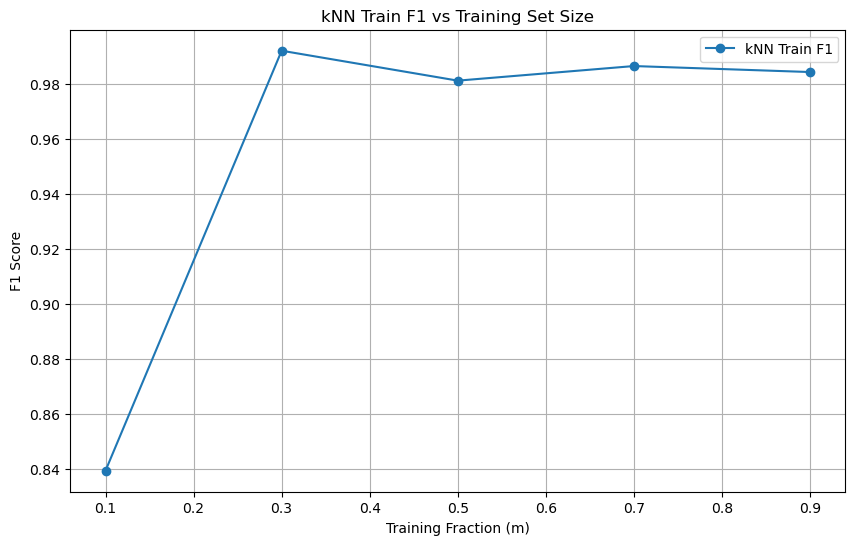

In [8]:
plt.figure(figsize=(10, 6))
plt.plot(fractions, train_scores, marker='o', label='kNN Train F1')

plt.xlabel("Training Fraction (m)")
plt.ylabel("F1 Score")
plt.title("kNN Train F1 vs Training Set Size")
plt.grid(True)
plt.legend()
plt.show()

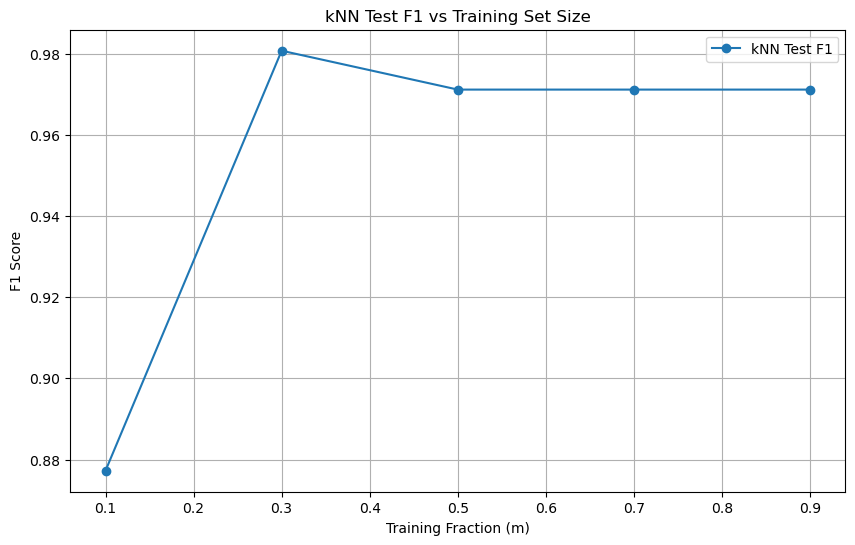

In [9]:
plt.figure(figsize=(10, 6))
plt.plot(fractions, test_scores, marker='o', label='kNN Test F1')

plt.xlabel("Training Fraction (m)")
plt.ylabel("F1 Score")
plt.title("kNN Test F1 vs Training Set Size")
plt.grid(True)
plt.legend()
plt.show()